Maria Navarro  
February 27, 2024  
Healthcare Data & Analytics Case Study: Insurance Claims Data & Analytics

Context:
This homework lays out your first basic analytics on the most important source of data in market for health, the Insurance Claims Data also known as Administrative Claims Data. We use an All Payer Claim Data APCD available to us from year 2016. APCD databases have the advantage of reflecting health and utilization data on all demographic groups rather than only one segment of the population which is the case for Medicare Claims. It means that data in APCD come from Medicare, Medicaid, and all major Commercial Insurances that are actively licensed in the APCD issuing state. The databases are relatively large and will be made available to you by your TA. These databases consist of inpatient discharge data, outpatient procedures and services data, and emergency department data. The outpatient claims are limited to the services rendered in the outpatient department of the hospitals and do not include non-hospital outpatient services and physician offices.  Each data set includes:
-	Case-specific diagnostic discharge data
-	Some widely specified socio-demographic characteristics of the patient. Hint: this data is highly de-identified so only some limited demographics and address data are reported to protect patients’ privacy (e.g. 3-digit zip code instead of 5 digit or age brackets instead of real age or DOBs.)  
-	Medical reason for the admission
-	Treatment and services provided to the patient
-	Duration and status of the patient's stay in the hospital
-	Full, undiscounted total and service-specific charges billed by the hospital. Hint: these are what hospitals have charged and does not necessarily mean they would receive the exact amount from the insurance. 
 We are using the year 2016 databases and codebooks, also available to you thru this HW and along with data files.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Read text files
inp = pd.read_csv('VTINP16_upd/VTINP16_upd.txt', delimiter=',')  # Assuming comma-separated values
ed = pd.read_csv('VTED16/vted16.txt', delimiter=',')
outp = pd.read_csv('VTOUTP16/VTOUTP16.txt', delimiter=',')
rev = pd.read_csv('VTREVCODE16/VTREVCODE16.txt', delimiter=',')


C:\Users\mfncn\AppData\Local\Temp\ipykernel_11888\2613644106.py:2: DtypeWarning: Columns (2,5,8,54,55,73,74,75,76,78) have mixed types. Specify dtype option on import or set low_memory=False.
  inp = pd.read_csv('VTINP16_upd/VTINP16_upd.txt', delimiter=',')  # Assuming comma-separated values
C:\Users\mfncn\AppData\Local\Temp\ipykernel_11888\2613644106.py:3: DtypeWarning: Columns (2,5,8,54,55,56,57,69) have mixed types. Specify dtype option on import or set low_memory=False.
  ed = pd.read_csv('VTED16/vted16.txt', delimiter=',')
C:\Users\mfncn\AppData\Local\Temp\ipykernel_11888\2613644106.py:4: DtypeWarning: Columns (2,5,54,55,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  outp = pd.read_csv('VTOUTP16/VTOUTP16.txt', delimiter=',')
C:\Users\mfncn\AppData\Local\Temp\ipykernel_11888\2613644106.py:5: DtypeWarning: Columns (6,7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  rev = pd.read_csv('VTREVCODE16/VTREVCODE16.txt', de

**Question 1: Patient Vignettes**  
Write a telling story for each of the following patients using their UNIQ identifier

##### uniq = 690326

In [33]:
uniq = 690326

# Check Emergency department first to see if the patient pathway began from the ED
# print(ed[ed['UNIQ']==uniq]) # empty dataframe

# Move onto the inpatient database
uniq_df = inp[inp['UNIQ'] == uniq] # found

# Check if the DataFrame has exactly one row
if len(uniq_df) == 1:
    # Access the single row using iloc[0]
    row = uniq_df.iloc[0]
    
    # Iterate over index-value pairs of the row
    for column, value in row.items():
        print(f"{column}: {value}")
else:
    print("DataFrame does not have exactly one row.")

hnum2: 5
ATYPE: 3
asour: 3
intage: 7
TXTZIP: 05468
sex: 2
dstat: 5
PPAY: 8
CHRGS: 43425.53
DX1: Z411
DX2: L299
DX3: R000
DX4: M62838
DX5: Z9884
DX6:  
DX7:  
DX8:  
DX9:  
DX10:  
DX11:  
DX12:  
DX13:  
DX14:  
DX15:  
DX16:  
DX17:  
DX18:  
DX19:  
DX20:  
PX1: 0H0V0ZZ
PX2: 0W0F0ZZ
PX3:  
PX4:  
PX5:  
PX6:  
PX7:  
PX8:  
PX9:  
PX10:  
PX11:  
PX12:  
PX13:  
PX14:  
PX15:  
PX16:  
PX17:  
PX18:  
PX19:  
PX20:  
ECODE1:  
ECODE2:  
ECODE3:  
hsa: 2
pdays: 3
ccsdx: 259
ccsdxgrp: 18
CCSPX: 175
CCSPXGRP: 15
ccsppx: 175
ccsppxgrp: 15
ccsproc: 175
ccsprocgrp: 15
DY: 2016
RECNO: 17818
BTYPE: 111
ERFLAG: 0
cah: 0
vtres: 1
OBSFLAG: 0
AFLAG: 1
UNIQ: 690326
ADMID_QTR: 2
DISCD_QTR: 2
CHRGS_HCIA: 43425.53
SCUD: 0
DRG: 581
MDC: 9
sdf: 0
GROUPER: 33


In [31]:
# Join the inpatient file to revenue code using the variable uniq where all the details of the services rendered to the patient are listed
# In explaining major services rendered to the patient use the REVCODE variable

rev[rev['Uniq'] == uniq].sort_values('REVCHRGS')

,dy,hnum2,DISCD_QTR,BTYPE,Uniq,REVCODE,REVCHRGS,REVUNITS,CPT,PCCR,PRIMARY_CPT,SFLAG,ccsproc,ccsprocgrp
2722834,2016,5,2,111,690326,730,52.0,1,93005,3280,0,0,,
2722832,2016,5,2,111,690326,410,111.68,1,36600,4900,0,1,,
2722825,2016,5,2,111,690326,271,146.18,1,,5500,0,0,,
2722828,2016,5,2,111,690326,310,273.98,2,88305,3420,0,0,,
2722827,2016,5,2,111,690326,300,327.75,8,85025,3390,0,0,,
2722826,2016,5,2,111,690326,272,642.32,11,,5500,0,0,,
2722833,2016,5,2,111,690326,710,847.78,1,,3800,0,0,,
2722835,2016,5,2,111,690326,921,1094.05,1,93970,3650,0,0,,
2722824,2016,5,2,111,690326,250,1351.25,568,J2704,5600,0,0,,
2722829,2016,5,2,111,690326,352,3273.01,1,71260,3230,0,0,,


uniq = 690326
Hospital num: University of Vermont Medical Center
Admission type: elective
admission source: NON-HEALTH CARE FACILITY POINT OF ORIGIN
discahrge status: home - own or family care
age group: 40-44
sex: female
principal payment source: self pay
charges: 43,425

diagnosis:
DX1: Z411 Encounter for cosmetic surgery
DX2: L299 Dermatological condition unspecified, unspecified pruritus,
DX3: R000 Tachycardia, unspecified.
DX4: M62838 Other muscle spasm
DX5: Z9884 Bariatric surgery status

procedure:
PX1: 0H0V0ZZ open approach to bilateral breast alteration
PX2: 0W0F0ZZ open approach alteration of the abdominal wall

major services rendered (revcode):
operating room services = 26k
room and board = 5k
anesthesia = 5k
ct scan body = 3k
pharmacy = 1k
Other Diagnostic Services: Peripheral vascular lab = 1k
recovery room = 800

pdays in the hospital = 3


At the University of Vermont Medical Center, a 40 to 44-year-old female patient with the unique identifier 690326 underwent elective admission from a non-health care facility point of origin. She sought cosmetic surgery to address personal concerns, opting for self-pay arrangements. The primary diagnosis, "Encounter for cosmetic surgery" (Z411), indicated her intent for aesthetic enhancement. During her stay, the patient experienced tachycardia (R000), unspecified dermatological conditions causing pruritus (L299), muscle spasms (M62838), and the aftermath of bariatric surgery (Z9884). The patient underwent two procedures: an "open approach to bilateral breast alteration" (PX1: 0H0V0ZZ) and an "open approach alteration of the abdominal wall" (PX2: 0W0F0ZZ). Over the course of three days, the patient received various services. The operating room services totaled around $26,000, covering surgical interventions. Room and board expenses amounted to $5,000, anesthesia services to $5,000, and diagnostic services (including a CT scan and peripheral vascular lab tests) to $4,000. Pharmacy services accounted for $1,000, and the recovery room for $800. Upon discharge, the patient returned home under family care.

##### uniq = 3692

In [39]:
uniq = 3692

# Check Emergency department first to see if the patient pathway began from the ED
ed_df = ed[ed['UNIQ']==uniq]
print(ed_df) # found

# Check if the DataFrame has exactly one row
if len(ed_df) == 1:
    # Access the single row using iloc[0]
    row = ed_df.iloc[0]
    
    # Iterate over index-value pairs of the row
    for column, value in row.items():
        print(f"{column}: {value}")
else:
    print("DataFrame does not have exactly one row.")

    hnum2  ATYPE asour  intage TXTZIP sex  dstat  PPAY      CHRGS   DX1  ...  \
18      5      2     3       3  05468   1      5     6  117895.29  F312  ...   

   BTYPE ERFLAG cah vtres OBSFLAG AFLAG  UNIQ ADMID_QTR DISCD_QTR CHRGS_HCIA  
18   111      1   0     1       0     0  3692         4         1  117895.29  

[1 rows x 70 columns]
hnum2: 5
ATYPE: 2
asour: 3
intage: 3
TXTZIP: 05468
sex: 1
dstat: 5
PPAY: 6
CHRGS: 117895.29
DX1: F312
DX2: R45851
DX3: Z87820
DX4: F1220
DX5: F17210
DX6: M722
DX7: K5900
DX8: S92025A
DX9: Y040XXA
DX10: Y9389
DX11: Y92238
DX12:  
DX13:  
DX14:  
DX15:  
DX16:  
DX17:  
DX18:  
DX19:  
DX20:  
PX1: HZ99ZZZ
PX2: HZ2ZZZZ
PX3:  
PX4:  
PX5:  
PX6:  
PX7:  
PX8:  
PX9:  
PX10:  
PX11:  
PX12:  
PX13:  
PX14:  
PX15:  
PX16:  
PX17:  
PX18:  
PX19:  
PX20:  
ECODE1: Y040XXA
ECODE2: Y9389
ECODE3: Y92238
hsa: 2
pdays: 58
ccsdx: 657
ccsdxgrp: 5
ccsproc: 219
ccsprocgrp: 16
DY: 2016
RECNO: 400
BTYPE: 111
ERFLAG: 1
cah: 0
vtres: 1
OBSFLAG: 0
AFLAG: 0
UNIQ: 3692
A

'\n# Move onto the inpatient database\nuniq_df = inp[inp[\'UNIQ\'] == uniq] # found\n\n# Check if the DataFrame has exactly one row\nif len(uniq_df) == 1:\n    # Access the single row using iloc[0]\n    row = uniq_df.iloc[0]\n    \n    # Iterate over index-value pairs of the row\n    for column, value in row.items():\n        print(f"{column}: {value}")\nelse:\n    print("DataFrame does not have exactly one row.")\n'

In [40]:
# Move onto the inpatient database
uniq_df = inp[inp['UNIQ'] == uniq] # found

# Check if the DataFrame has exactly one row
if len(uniq_df) == 1:
    # Access the single row using iloc[0]
    row = uniq_df.iloc[0]
    
    # Iterate over index-value pairs of the row
    for column, value in row.items():
        print(f"{column}: {value}")
else:
    print("DataFrame does not have exactly one row.")

hnum2: 5
ATYPE: 2
asour: 3
intage: 3
TXTZIP: 05468
sex: 1
dstat: 5
PPAY: 6
CHRGS: 117895.29
DX1: F312
DX2: R45851
DX3: Z87820
DX4: F1220
DX5: F17210
DX6: M722
DX7: K5900
DX8: S92025A
DX9: Y040XXA
DX10: Y9389
DX11: Y92238
DX12:  
DX13:  
DX14:  
DX15:  
DX16:  
DX17:  
DX18:  
DX19:  
DX20:  
PX1: HZ99ZZZ
PX2: HZ2ZZZZ
PX3:  
PX4:  
PX5:  
PX6:  
PX7:  
PX8:  
PX9:  
PX10:  
PX11:  
PX12:  
PX13:  
PX14:  
PX15:  
PX16:  
PX17:  
PX18:  
PX19:  
PX20:  
ECODE1: Y040XXA
ECODE2: Y9389
ECODE3: Y92238
hsa: 2
pdays: 58
ccsdx: 657
ccsdxgrp: 5
CCSPX: 219
CCSPXGRP: 16
ccsppx:  
ccsppxgrp:  
ccsproc:  
ccsprocgrp:  
DY: 2016
RECNO: 400
BTYPE: 111
ERFLAG: 1
cah: 0
vtres: 1
OBSFLAG: 0
AFLAG: 0
UNIQ: 3692
ADMID_QTR: 4
DISCD_QTR: 1
CHRGS_HCIA: 117895.29
SCUD: 0
DRG: 885
MDC: 19
sdf: 0
GROUPER: 33


In [41]:
# Join the inpatient file to revenue code using the variable uniq where all the details of the services rendered to the patient are listed
# In explaining major services rendered to the patient use the REVCODE variable

rev[rev['Uniq'] == uniq].sort_values('REVCHRGS')

,dy,hnum2,DISCD_QTR,BTYPE,Uniq,REVCODE,REVCHRGS,REVUNITS,CPT,PCCR,PRIMARY_CPT,SFLAG,ccsproc,ccsprocgrp
21596,2016,5,1,111,3692,730,52.0,1,93005,3280,0,0,,
21593,2016,5,1,111,3692,300,1716.92,31,82247,3390,0,0,,
21594,2016,5,1,111,3692,320,1873.08,4,73610,4100,0,0,,
21595,2016,5,1,111,3692,450,1983.03,1,99285,6100,1,0,888,
21592,2016,5,1,111,3692,250,5608.26,843,,5600,0,0,,
21591,2016,5,1,111,3692,124,106662.0,58,,,0,0,,


uniq = 3692
Hospital num: University of Vermont Medical Center
Admission type: urgent 
admission source: NON-HEALTH CARE FACILITY POINT OF ORIGIN
discharge status: HOME - OWN OR FAMILY CARE
age group: 18-24
sex: male
principal payment source: BLUE CROSS
charges: 117,895

diagnosis:
F312: bipolar disorder, current episode manic severe with psychotic features
R45851: suicidal ideations
Z87820: personal history of traumatic brain injury (TBI)
F1220: Cannabis dependence
F17210: Nicotine dependence, cigarettes, uncomplicated
M722: plantar fascial fibromatosis
K5900: unspecified constipation
S92025A: nondisplaced fracture of the anterior process of the left calcaneus, as well as an initial encounter for a closed fracture
Y040XXA: initial encounter of an unarmed brawl or fight assault

procedure:
HZ99ZZZ: pharmacotherapy for substance abuse treatment, other replacement medication
HZ2ZZZZ: Detoxification Services for Substance Abuse Treatment

major services rendered (revcode):
room and board psychiatric for 58 days = 100k
pharmacy = 5k
emergency room = 2k
radiology diagnostic = 2k
Laboratory - Clinical Diagnostic = 2k


pdays in the hospital: 58

At the University of Vermont Medical Center, an urgent admission was received for a male patient, identified as 3692, from a non-health care facility point of origin. This young adult, aged 18 to 24, presented with a complex array of mental health diagnoses, including bipolar disorder with severe manic episodes and psychotic features, suicidal ideations, and a personal history of traumatic brain injury. Additionally, he struggled with substance dependence, including cannabis and nicotine, as well as a variety of physical health issues such as plantar fascial fibromatosis and a non-displaced fracture of the anterior process of the left calcaneus from an assault encounter. The patient's principal payment source for his care was through Blue Cross insurance. Urgent and intensive psychiatric care was provided over a 58-day hospital stay to address his complex needs. During this time, he underwent pharmacotherapy for substance abuse treatment and detoxification services, aimed at addressing his substance dependence. Throughout his hospitalization, the patient received comprehensive services. These included psychiatric room and board services, pharmacy services for medication management, emergency room interventions during critical moments, diagnostic imaging through radiology, and clinical laboratory diagnostics for comprehensive assessment and monitoring. The costs associated with the patient's care were significant. Psychiatric room and board services for the 58-day duration amounted to $100,000, reflecting the extended duration of his hospital stay. Pharmacy services for medication management totaled $5,000, covering the various medications prescribed to address his mental health and physical issues. Emergency room interventions incurred expenses of $2,000, reflecting acute interventions during critical moments. Diagnostic imaging through radiology amounted to $2,000, utilized for diagnostic purposes and treatment planning. Clinical laboratory diagnostics for comprehensive assessment and monitoring contributed an additional $2,000 to the overall costs. The patient's journey culminated in a discharge to the care of his own family.

##### uniq = 200760

In [42]:
uniq = 200760

# Check Emergency department first to see if the patient pathway began from the ED
ed_df = ed[ed['UNIQ']==uniq]
print(ed_df) # found

# Check if the DataFrame has exactly one row
if len(ed_df) == 1:
    # Access the single row using iloc[0]
    row = ed_df.iloc[0]
    
    # Iterate over index-value pairs of the row
    for column, value in row.items():
        print(f"{column}: {value}")
else:
    print("DataFrame does not have exactly one row.")

      hnum2  ATYPE asour  intage TXTZIP sex  dstat  PPAY     CHRGS      DX1  \
2687      5      1     3       3    054   2      6     7  49533.15  S8252XA   

      ... BTYPE ERFLAG cah vtres OBSFLAG AFLAG    UNIQ ADMID_QTR DISCD_QTR  \
2687  ...   111      1   0     1       0     1  200760         1         1   

     CHRGS_HCIA  
2687   49533.15  

[1 rows x 70 columns]
hnum2: 5
ATYPE: 1
asour: 3
intage: 3
TXTZIP: 054
sex: 2
dstat: 6
PPAY: 7
CHRGS: 49533.15
DX1: S8252XA
DX2: S82402A
DX3: K219
DX4: F329
DX5: V892XXA
DX6:  
DX7:  
DX8:  
DX9:  
DX10:  
DX11:  
DX12:  
DX13:  
DX14:  
DX15:  
DX16:  
DX17:  
DX18:  
DX19:  
DX20:  
PX1: 0QSH04Z
PX2: 0QSK06Z
PX3:  
PX4:  
PX5:  
PX6:  
PX7:  
PX8:  
PX9:  
PX10:  
PX11:  
PX12:  
PX13:  
PX14:  
PX15:  
PX16:  
PX17:  
PX18:  
PX19:  
PX20:  
ECODE1: V892XXA
ECODE2:  
ECODE3:  
hsa: 2
pdays: 4
ccsdx: 230
ccsdxgrp: 16
ccsproc: 147
ccsprocgrp: 14
DY: 2016
RECNO: 5469
BTYPE: 111
ERFLAG: 1
cah: 0
vtres: 1
OBSFLAG: 0
AFLAG: 1
UNIQ: 200760
ADM

In [43]:
# Move onto the inpatient database
uniq_df = inp[inp['UNIQ'] == uniq] # found

# Check if the DataFrame has exactly one row
if len(uniq_df) == 1:
    # Access the single row using iloc[0]
    row = uniq_df.iloc[0]
    
    # Iterate over index-value pairs of the row
    for column, value in row.items():
        print(f"{column}: {value}")
else:
    print("DataFrame does not have exactly one row.")

hnum2: 5
ATYPE: 1
asour: 3
intage: 3
TXTZIP: 054
sex: 2
dstat: 6
PPAY: 7
CHRGS: 49533.15
DX1: S8252XA
DX2: S82402A
DX3: K219
DX4: F329
DX5: V892XXA
DX6:  
DX7:  
DX8:  
DX9:  
DX10:  
DX11:  
DX12:  
DX13:  
DX14:  
DX15:  
DX16:  
DX17:  
DX18:  
DX19:  
DX20:  
PX1: 0QSH04Z
PX2: 0QSK06Z
PX3:  
PX4:  
PX5:  
PX6:  
PX7:  
PX8:  
PX9:  
PX10:  
PX11:  
PX12:  
PX13:  
PX14:  
PX15:  
PX16:  
PX17:  
PX18:  
PX19:  
PX20:  
ECODE1: V892XXA
ECODE2:  
ECODE3:  
hsa: 2
pdays: 4
ccsdx: 230
ccsdxgrp: 16
CCSPX: 147
CCSPXGRP: 14
ccsppx: 147
ccsppxgrp: 14
ccsproc: 147
ccsprocgrp: 14
DY: 2016
RECNO: 5469
BTYPE: 111
ERFLAG: 1
cah: 0
vtres: 1
OBSFLAG: 0
AFLAG: 1
UNIQ: 200760
ADMID_QTR: 1
DISCD_QTR: 1
CHRGS_HCIA: 49533.15
SCUD: 0
DRG: 494
MDC: 8
sdf: 0
GROUPER: 33


In [44]:
# Join the inpatient file to revenue code using the variable uniq where all the details of the services rendered to the patient are listed
# In explaining major services rendered to the patient use the REVCODE variable

rev[rev['Uniq'] == uniq].sort_values('REVCHRGS')

,dy,hnum2,DISCD_QTR,BTYPE,Uniq,REVCODE,REVCHRGS,REVUNITS,CPT,PCCR,PRIMARY_CPT,SFLAG,ccsproc,ccsprocgrp
801754,2016,5,1,111,200760,420,138.63,1,97530,5000,0,0,,
801755,2016,5,1,111,200760,424,350.34,1,97001,5000,0,0,,
801748,2016,5,1,111,200760,272,409.96,12,,5500,0,0,,
801750,2016,5,1,111,200760,300,610.08,17,85025,3390,0,0,,
801751,2016,5,1,111,200760,320,833.28,2,73590,4100,0,0,,
801747,2016,5,1,111,200760,250,1387.36,321,,5600,0,0,,
801756,2016,5,1,111,200760,450,2582.43,4,96361,6100,0,0,,
801753,2016,5,1,111,200760,370,2590.07,227,,4000,0,0,,
801746,2016,5,1,111,200760,120,6768.0,4,,,0,0,,
801749,2016,5,1,111,200760,278,10696.77,14,C1713,5530,0,0,,


uniq = 200760
Hospital num: University of Vermont Medical Center
Admission type: emergency
admission source: NON-HEALTH CARE FACILITY POINT OF ORIGIN
discharge status: HOME - HOME HEALTH
age group: 18-24
sex: female
principal payment source: COMMERCIAL INSURANCE
charges: 49,533

diagnosis:
DX1: S8252XA displaced fracture of the medial malleolus of the left tibia, with an initial encounter for a closed fracture.
DX2: S82402A nspecified fracture of shaft of left fibula, initial encounter for closed fracture
DX3: K219 gastro-esophageal reflux disease (GERD) without esophagitis
DX4: F329 major depressive disorder, single episode, unspecified
DX5: V892XXA indicates a person has been injured in an unspecified motor-vehicle accident

procedure:
PX1: 0QSH04Z Reposition Left Tibia with Internal Fixation Device, Open Approach
PX2: 0QSK06Z Reposition left fibula with intramedullary internal fixation device, open approach

major services rendered (revcode):
Operating Room Services = 14k
Medical/Surgical Supplies: Other implants = 10k
Room and board = 7k
Anesthesia = 3k
Emergency room = 3k
Pharmacy = 1k
Radiology Diagnostic = 1k
Other minor sercices: laboratory clinical diagnostic, Physical Therapy: Evaluation/re-evaluation, Physical Therapy

pdays in the hospital: 4

Total charges: $49,533  
At the University of Vermont Medical Center, an emergency admission was received for a female patient, identified as 200760, from a non-health care facility point of origin. This young adult, aged 18 to 24, experienced traumatic injuries requiring urgent medical attention. The principal payment source for her care was through commercial insurance. The patient's admission was prompted by a series of traumatic injuries, including a displaced fracture of the medial malleolus of the left tibia and an unspecified fracture of the shaft of the left fibula. These injuries were the result of an unspecified motor vehicle accident. Additionally, she was diagnosed with gastro-esophageal reflux disease (GERD) without esophagitis and major depressive disorder, highlighting the complex nature of her health concerns. Urgent surgical interventions were required to address the patient's fractures. Procedures such as "Reposition Left Tibia with Internal Fixation Device, Open Approach" and "Reposition left fibula with intramedullary internal fixation device, open approach" were performed to stabilize her injuries and facilitate the healing process. During her four-day hospital stay, the patient received a range of services to support her recovery and well-being. These included medical/surgical supplies for implants, operating room services for surgical interventions, room and board expenses, anesthesia services for pain management, emergency room interventions, pharmacy services for medication management, and diagnostic imaging through radiology. The costs associated with the patient's care were significant. Operating room services incurred expenses of $14,000, covering the costs of surgical interventions. Medical/surgical supplies for implants accounted for $10,000, reflecting the use of specialized devices to stabilize her fractures. Room and board expenses amounted to $7,000. Anesthesia services totaled $3,000, essential for pain management during surgical procedures. Emergency room interventions and pharmacy services each amounted to $3,000 and $1,000 respectively, reflecting acute interventions and medication management. Additionally, diagnostic imaging through radiology contributed $1,000 to the overall costs. The patient's journey culminated in a discharge to home health care.

**Question 2: Service and Cost Profile of Major Insurances**

Inpatient hospitalizations are identified and priced and paid by DRGs (Diagnostic Related Groups). So each hospital admission has a DRG. To learn more a PDF file is also included in this package explaining how the DRG classification system works.  You can see the list of DRGs in the Excel file “FILE_LAYOUT_and_CODES”. DRGs are classified in Major Diagnosis Groups or MDCs. You can find the name of the MDCs in the same Excel file. This question uses the MDC as a high-level classifier for an aggregated view of hospital admissions rather than hundreds of individual DRGs.  

Identify the three major insurance payers: Medicare, Medicaid and then combine all hospital admissions of the two major commercial insurances of “BLUE CROSS” + “COMMERCIAL INSURANCE” and call this combined last category as Commercial Payers for this question. For the 3 insurances, create a cross tabulation with the MDC categories as row heading, and the name of the 3 insurances as the column headings. The cell values of your X-tab would be the sum of the dollar value of the charges for the selected MDC for each of the 3 insurances.  Turn all your dollar values to $Million and round the value to drop any decimal points so you do not overwhelm your x-tab presentation with so many multiple digits figures. Drop all non-classified, unknown, and missing value rows from your x-tab and stay focus on the known MDCs only. 


In [122]:
inp

,hnum2,ATYPE,asour,intage,TXTZIP,sex,dstat,PPAY,CHRGS,DX1,...,AFLAG,UNIQ,ADMID_QTR,DISCD_QTR,CHRGS_HCIA,SCUD,DRG,MDC,sdf,GROUPER
0,11,3,1,14,050,2,6,1,67375.25,Z5189,...,1,254,4,1,67375.25,,949,23,0,33
1,11,3,3,14,050,1,2,1,22886,Z5189,...,0,265,4,1,22886,,949,23,0,33
2,11,3,1,14,057,2,2,1,120544.05,Z4789,...,0,271,4,1,120544.05,,560,8,0,33
3,11,3,1,14,051,2,6,1,32325.8,S72001D,...,0,285,4,1,32325.8,,561,8,0,33
4,11,3,1,12,050,2,6,7,29244.1,C3490,...,0,305,4,1,29244.1,,181,4,0,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53662,5,1,3,12,05452,1,7,1,10714.04,I5023,...,0,1984299,4,4,10714.04,0,291,5,0,34
53663,5,1,3,3,054,2,5,6,3529.4,O2342,...,0,1984384,4,4,3529.4,0,781,14,0,34
53664,5,1,3,2,05446,2,5,8,7112.75,D693,...,0,1984386,4,4,7112.75,0,813,16,0,34
53665,5,1,2,14,054,1,8,1,13312.85,J9601,...,0,1984415,4,4,13312.85,0,189,4,0,34


In [123]:
inp.columns

Index(['hnum2', 'ATYPE', 'asour', 'intage', 'TXTZIP', 'sex', 'dstat', 'PPAY',
       'CHRGS', 'DX1', 'DX2', 'DX3', 'DX4', 'DX5', 'DX6', 'DX7', 'DX8', 'DX9',
       'DX10', 'DX11', 'DX12', 'DX13', 'DX14', 'DX15', 'DX16', 'DX17', 'DX18',
       'DX19', 'DX20', 'PX1', 'PX2', 'PX3', 'PX4', 'PX5', 'PX6', 'PX7', 'PX8',
       'PX9', 'PX10', 'PX11', 'PX12', 'PX13', 'PX14', 'PX15', 'PX16', 'PX17',
       'PX18', 'PX19', 'PX20', 'ECODE1', 'ECODE2', 'ECODE3', 'hsa', 'pdays',
       'ccsdx', 'ccsdxgrp', 'CCSPX', 'CCSPXGRP', 'ccsppx', 'ccsppxgrp',
       'ccsproc', 'ccsprocgrp', 'DY', 'RECNO', 'BTYPE', 'ERFLAG', 'cah',
       'vtres', 'OBSFLAG', 'AFLAG', 'UNIQ', 'ADMID_QTR', 'DISCD_QTR',
       'CHRGS_HCIA', 'SCUD', 'DRG', 'MDC', 'sdf', 'GROUPER'],
      dtype='object')

In [124]:
inp['PPAY'].value_counts()
# 1 = medicare, 2 = medicaid, 6 = blue cross, 7 = commercial insurance

PPAY
1     24029
2     10689
6      9601
7      6229
12     1206
8       770
0       390
11      377
5       206
4       123
10       47
Name: count, dtype: int64

In [125]:
major_payers = [1, 2, 6, 7]

# Define condition
condition = inp['PPAY'].isin(major_payers)

# Filter rows based on condition
inp2 = pd.DataFrame()
inp2 = inp[condition].copy()

In [126]:
# Creating new payer column
condition_medicare = inp2['PPAY'] == 1
condition_medicaid = inp2['PPAY'] == 2
condition_commercial = (inp2['PPAY'] == 6) | (inp2['PPAY'] == 7)

inp2.loc[condition_medicare, 'payer'] = 'medicare'
inp2.loc[condition_medicaid, 'payer'] = 'medicaid'
inp2.loc[condition_commercial, 'payer'] = 'commercial'

In [127]:
inp2['PPAY'].value_counts()

PPAY
1    24029
2    10689
6     9601
7     6229
Name: count, dtype: int64

In [128]:
inp2['payer'].value_counts()

payer
medicare      24029
commercial    15830
medicaid      10689
Name: count, dtype: int64

In [129]:
inp2['MDC'].value_counts()

MDC
8     4212
4     3547
5     3536
14    3247
15    2941
6     2748
5     2511
8     2326
15    2165
14    2043
4     1903
1     1727
18    1709
6     1610
1     1376
11    1196
18    1116
19    1107
7      934
10     838
11     767
9      688
7      593
19     582
10     542
23     536
21     406
20     374
9      371
23     330
16     320
21     298
3      238
16     226
17     210
17     180
20     180
13     160
3      149
12     130
13     127
12      86
24      84
24      79
2       21
2       20
22      18
22      16
25       9
         8
25       8
Name: count, dtype: int64

In [130]:
# Replace empty strings with NaN in the specified column
inp2['MDC'].replace(' ', np.nan, inplace=True)

# Drop rows with null values in the 'CHRGS' and 'MDC' column
inp2.dropna(subset=['CHRGS', 'MDC'], inplace=True)

# Convert 'CHRGS' column to numeric
inp2['CHRGS'] = pd.to_numeric(inp2['CHRGS'], errors='coerce')

# Convert 'MDC' column to numeric
inp2['MDC'] = inp2['MDC'].astype(str)

C:\Users\mfncn\AppData\Local\Temp\ipykernel_12300\709091445.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  inp2['MDC'].replace(' ', np.nan, inplace=True)


In [131]:
inp2['MDC'].value_counts()

MDC
8     6538
5     6047
4     5450
14    5290
15    5106
6     4358
1     3103
18    2825
11    1963
19    1689
7     1527
10    1380
9     1059
23     866
21     704
20     554
16     546
17     390
3      387
13     287
12     216
24     163
2       41
22      34
25      17
Name: count, dtype: int64

In [132]:
# Create a cross tabulation with the MDC categories as row heading, and the name of the 3 insurances as the column headings. The cell values of your X-tab would be the sum of the dollar value of the charges for the selected MDC for each of the 3 insurances.  
cross_tab = pd.crosstab(inp2['MDC'], inp2['payer'], values=inp2['CHRGS'], aggfunc='sum')

# Divide the values by 1 million
cross_tab = cross_tab / 1000000

# Round the values to drop decimal points
cross_tab = cross_tab.round(0)

# Convert the cross-tabulation values to integers
cross_tab = cross_tab.astype(int)

# Print the cross-tabulation
print(cross_tab)


payer  commercial  medicaid  medicare
MDC                                  
1              38        14        57
10              9         6        13
11              8         4        28
12              2         0         3
13              4         2         2
14             34        26         1
15             28        31         0
16              5         3         7
17              6         3         8
18             18        14        61
19             10        15        25
2               0         0         0
20              1         4         3
21              4         4         9
22              0         1         1
23              6         3        15
24              8         3         4
25              0         0         0
3               3         2         4
4              24        22        78
5              54        15       136
6              32        14        63
7              12        11        18
8              88        30       146
9           

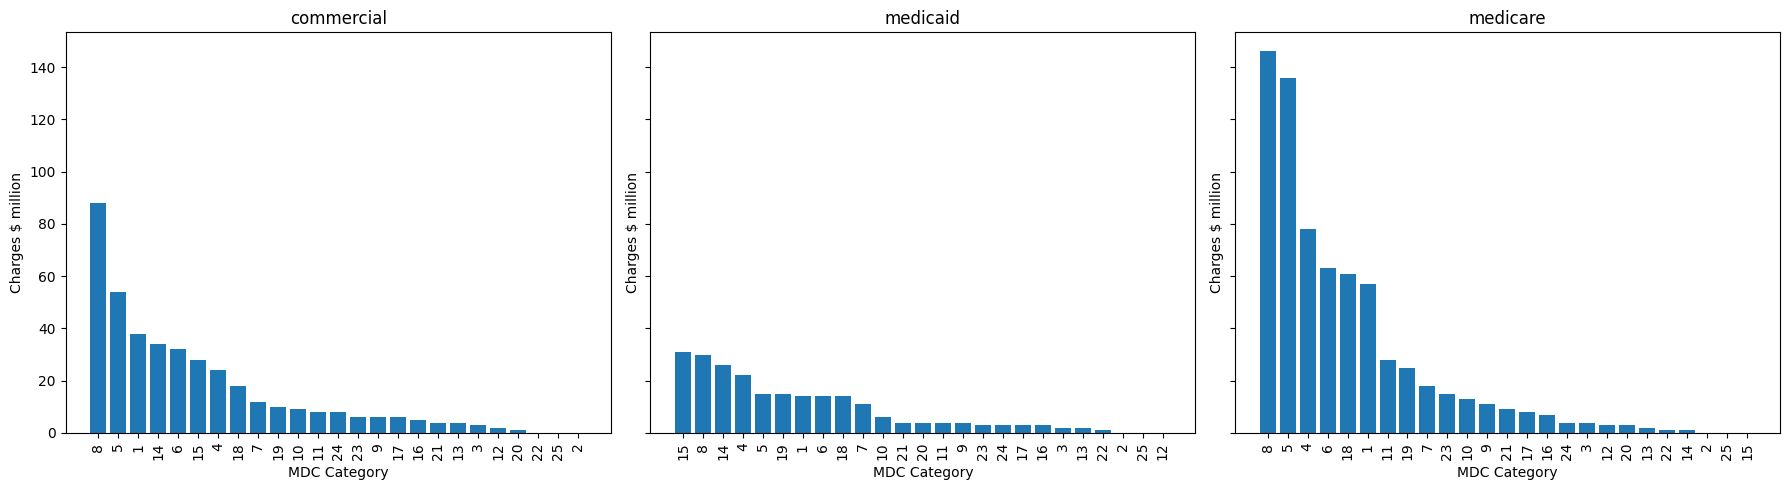

In [139]:
# Sort values in each payer's series in descending order
sorted_cross_tab = cross_tab.apply(lambda x: x.sort_values(ascending=False), axis=0)

# Plot bar charts for each payer with sorted values
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, (payer, data) in enumerate(sorted_cross_tab.items()):
    ax = axs[i]
    sorted_data = data.sort_values(ascending=False)  # Sort data in descending order
    ax.bar(sorted_data.index, sorted_data, color='C0')  # Plot bars with sorted data
    ax.set_title(payer)
    ax.set_xlabel('MDC Category')
    ax.set_ylabel('Charges $ million')
    plt.sca(ax)
    plt.xticks(rotation=90)  # Rotate x-axis labels

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()